# Ambiente Miniconda

Execute no PowerShell, uma linha por vez:

```powershell
conda create -n projeto_dados python=3.11 -y
conda activate projeto_dados
conda install -c conda-forge pandas matplotlib ipykernel -y
python -m ipykernel install --user --name projeto_dados --display-name "Python (projeto_dados)"
```

No VS Code, selecione o kernel `Python (projeto_dados)` antes de executar as células.

# 1. Crescimento econômico

Para comparar o período coberto pelas principais séries internacionais, usamos 2004 como ano inicial e como base do índice do PIB real per capita.

$$Indice_t = \frac{PIBpc_t}{PIBpc_{2004}} \times 100$$

Assim, cada país começa em 100 em 2004 e o gráfico mostra quanto o PIB per capita aumentou a partir desse período.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'API_NY.GDP.PCAP.KD_DS2_en_csv_v2_329799').exists():
    ROOT = Path(r'c:/Users/rofre/Documents/Engenharia Industrial/Introdução a Ciencia de Dados - Vahid/Projeto')

COUNTRIES = {
    'BRA': 'Brasil',
    'USA': 'EUA',
    'CHN': 'China',
}
BASE_YEAR = 2004
START_YEAR = 2004
END_YEAR = 2024
plt.style.use('seaborn-v0_8-whitegrid')

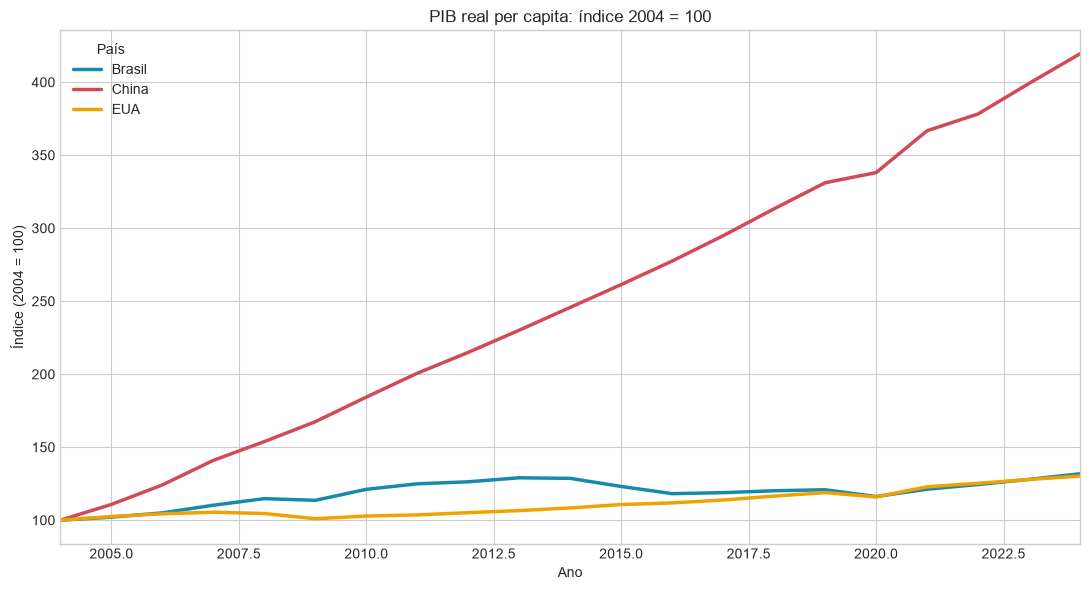

In [2]:
path = ROOT / 'API_NY.GDP.PCAP.KD_DS2_en_csv_v2_329799' / 'API_NY.GDP.PCAP.KD_DS2_en_csv_v2_329799.csv'
df = pd.read_csv(path, skiprows=4, engine='python')
year_columns = [column for column in df.columns if str(column).isdigit()]
df = df[['Country Code', *year_columns]].rename(columns={'Country Code': 'country'})
df = df[df['country'].isin(COUNTRIES)].copy()

gdp = df.melt(
    id_vars='country',
    value_vars=year_columns,
    var_name='year',
    value_name='gdp_per_capita',
)
gdp['year'] = pd.to_numeric(gdp['year'], errors='coerce')
gdp['gdp_per_capita'] = pd.to_numeric(gdp['gdp_per_capita'], errors='coerce')
gdp = gdp.dropna(subset=['year', 'gdp_per_capita'])
gdp = gdp[gdp['year'].between(START_YEAR, END_YEAR)]

base = (
    gdp[gdp['year'].eq(BASE_YEAR)][['country', 'gdp_per_capita']]
    .rename(columns={'gdp_per_capita': 'base_value'})
)
gdp_index = gdp.merge(base, on='country', validate='many_to_one')
gdp_index['index_base'] = gdp_index['gdp_per_capita'] / gdp_index['base_value'] * 100
gdp_index['country_name'] = gdp_index['country'].map(COUNTRIES)

gdp_index.pivot(index='year', columns='country_name', values='index_base').plot(
    figsize=(11, 6),
    linewidth=2.5,
    color=['#168aad', '#d1495b', '#f0a202'],
)
plt.title('PIB real per capita: índice 2004 = 100')
plt.xlabel('Ano')
plt.ylabel('Índice (2004 = 100)')
plt.legend(title='País')
plt.xlim(START_YEAR, END_YEAR)
plt.tight_layout()
plt.show()

## Interpretação

O país com maior valor no final da série foi aquele cujo PIB real per capita mais aumentou proporcionalmente desde 2004. A normalização elimina a diferença de nível inicial, permitindo comparar a trajetória de crescimento entre Brasil, EUA e China.

# 2. Quem recebeu essa renda?

O PIB mostra quanto a economia cresceu, mas não mostra quem recebeu esse crescimento. Para responder a essa pergunta, usamos a WID e acompanhamos a participação na renda nacional de quatro grupos a partir de 2004:

- Bottom 50%: `p0p50`
- Middle 40%: `p50p90`
- Top 10%: `p90p100`
- Top 1%: `p99p100`

Os três países serão apresentados com a mesma escala e o mesmo período para permitir uma comparação direta.

In [3]:
WID_COUNTRIES = {
    'BR': 'Brasil',
    'CN': 'China',
    'US': 'EUA',
}
WID_GROUPS = {
    'p0p50': 'Bottom 50%',
    'p50p90': 'Middle 40%',
    'p90p100': 'Top 10%',
    'p99p100': 'Top 1%',
}


def load_wid_income_share(country_code):
    path = ROOT / 'wid_all_data' / f'WID_data_{country_code}.csv'
    data = pd.read_csv(
        path,
        sep=';',
        usecols=['variable', 'percentile', 'year', 'value'],
        low_memory=False,
    )
    data['year'] = pd.to_numeric(data['year'], errors='coerce')
    data['value'] = pd.to_numeric(data['value'], errors='coerce')
    data = data.dropna(subset=['year', 'value'])

    variable = 'sptincj992'
    if variable not in set(data['variable'].dropna()):
        raise ValueError(
            f'Nenhuma variável sptinc encontrada para {country_code}. '
            f'Exemplos disponíveis: {sorted(data["variable"].dropna().unique())[:10]}'
        )

    result = data[
        data['variable'].eq(variable)
        & data['percentile'].isin(WID_GROUPS)
        & data['year'].between(START_YEAR, END_YEAR)
    ].copy()
    result['country'] = WID_COUNTRIES[country_code]
    result['group'] = result['percentile'].map(WID_GROUPS)
    result['share'] = result['value']
    if result['share'].max() <= 1.5:
        result['share'] = result['share'] * 100
    print(f'{country_code}: variável {variable}, anos {int(result["year"].min())}-{int(result["year"].max())}')
    return result[['country', 'year', 'group', 'share']].sort_values(['country', 'year', 'group'])


wid_income = pd.concat(
    [load_wid_income_share(code) for code in WID_COUNTRIES],
    ignore_index=True,
)
wid_income.head()

BR: variável sptincj992, anos 2004-2024


CN: variável sptincj992, anos 2004-2024


US: variável sptincj992, anos 2004-2024


,country,year,group,share
0,Brasil,2004,Bottom 50%,9.56
1,Brasil,2004,Middle 40%,32.26
2,Brasil,2004,Top 1%,28.11
3,Brasil,2004,Top 10%,58.18
4,Brasil,2005,Bottom 50%,9.07


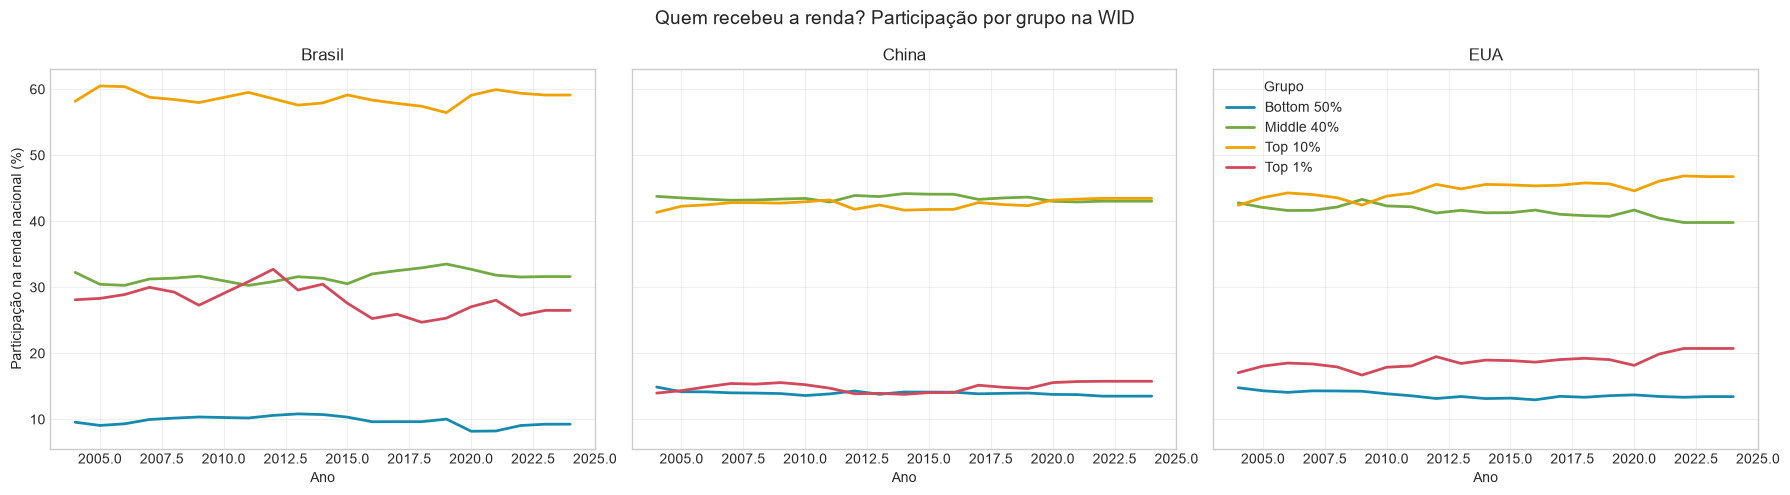

,country,year,group,share
80,Brasil,2024,Bottom 50%,9.26
81,Brasil,2024,Middle 40%,31.62
82,Brasil,2024,Top 1%,26.50
83,Brasil,2024,Top 10%,59.12
164,China,2024,Bottom 50%,13.51
165,China,2024,Middle 40%,43.04
166,China,2024,Top 1%,15.76
167,China,2024,Top 10%,43.46
248,EUA,2024,Bottom 50%,13.44
249,EUA,2024,Middle 40%,39.81


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
colors = {
    'Bottom 50%': '#168aad',
    'Middle 40%': '#73a942',
    'Top 10%': '#f0a202',
    'Top 1%': '#d1495b',
}

for axis, country in zip(axes, WID_COUNTRIES.values()):
    country_data = wid_income[wid_income['country'].eq(country)]
    for group, color in colors.items():
        group_data = country_data[country_data['group'].eq(group)]
        axis.plot(group_data['year'], group_data['share'], label=group, color=color, linewidth=2)
    axis.set_title(country)
    axis.set_xlabel('Ano')
    axis.grid(True, alpha=0.3)

axes[0].set_ylabel('Participação na renda nacional (%)')
axes[-1].legend(title='Grupo', loc='best')
fig.suptitle('Quem recebeu a renda? Participação por grupo na WID', fontsize=14)
fig.tight_layout()
plt.show()

latest_income = (
    wid_income.sort_values('year')
    .groupby(['country', 'group'], as_index=False)
    .tail(1)
    .sort_values(['country', 'group'])
)
latest_income[['country', 'year', 'group', 'share']]

# 3. PIB, produtividade e renda dos grupos

Agora comparamos, para cada país, a evolução relativa de:

- PIB real per capita;
- produtividade do trabalho;
- participação na renda do Bottom 50%;
- participação na renda do Top 10%;
- participação na renda do Top 1%.

Todas as séries são normalizadas para **2004 = 100**. A pergunta é quantitativa: o aumento da produção e da produtividade foi acompanhado proporcionalmente pela renda dos diferentes grupos?

In [5]:
ILOSTAT_COUNTRIES = {
    'BRA': 'Brasil',
    'USA': 'EUA',
    'CHN': 'China',
}

productivity_path = ROOT / 'GDP_211P_NOC_NB_A-20260919T1910.csv' / 'GDP_211P_NOC_NB_A-20260919T1910.csv'
productivity = pd.read_csv(productivity_path)
productivity = productivity.rename(
    columns={'ref_area': 'country', 'time': 'year', 'obs_value': 'value'}
)
productivity['year'] = pd.to_numeric(productivity['year'], errors='coerce')
productivity['value'] = pd.to_numeric(productivity['value'], errors='coerce')
productivity = productivity[
    productivity['country'].isin(ILOSTAT_COUNTRIES)
    & productivity['year'].between(START_YEAR, END_YEAR)
].dropna(subset=['year', 'value'])
productivity = productivity.rename(columns={'value': 'productivity'})
productivity['country_name'] = productivity['country'].map(ILOSTAT_COUNTRIES)
productivity.head()

,country,source,indicator,year,productivity,country_name
780,BRA,XA:2002,GDP_211P_NOC_NB,2024,41431.74,Brasil
781,BRA,XA:2002,GDP_211P_NOC_NB,2023,41147.83,Brasil
782,BRA,XA:2002,GDP_211P_NOC_NB,2022,40323.12,Brasil
783,BRA,XA:2002,GDP_211P_NOC_NB,2021,41904.57,Brasil
784,BRA,XA:2002,GDP_211P_NOC_NB,2020,41893.28,Brasil


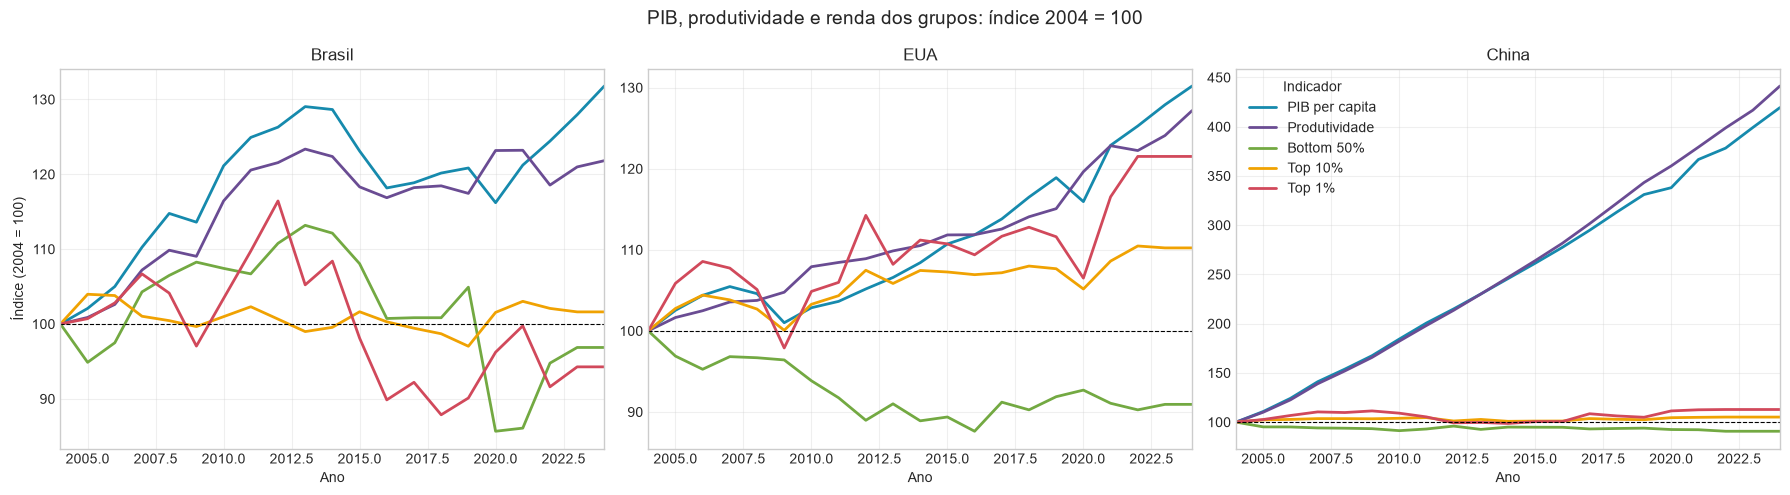

,country,year,metric,index
186,Brasil,2024,Bottom 50%,96.861925
60,Brasil,2024,PIB per capita,131.795464
63,Brasil,2024,Produtividade,121.816355
187,Brasil,2024,Top 1%,94.272501
188,Brasil,2024,Top 10%,101.615675
249,China,2024,Bottom 50%,90.732035
61,China,2024,PIB per capita,419.420282
84,China,2024,Produtividade,441.324257
250,China,2024,Top 1%,112.813171
251,China,2024,Top 10%,105.128205


In [6]:
def normalize_series(frame, group_column, value_column):
    base = (
        frame[frame['year'].eq(START_YEAR)][group_column + [value_column]]
        .rename(columns={value_column: 'base_value'})
    )
    result = frame.merge(base, on=group_column, validate='many_to_one')
    result['index_base'] = result[value_column] / result['base_value'] * 100
    return result


gdp_series = gdp_index[['year', 'country_name', 'index_base']].rename(
    columns={'country_name': 'country', 'index_base': 'index'}
)

economic_productivity = normalize_series(
    productivity[['country_name', 'year', 'productivity']].rename(
        columns={'country_name': 'country'}
    ),
    ['country'],
    'productivity',
)
economic_productivity = economic_productivity[['country', 'year', 'index_base']].rename(
    columns={'index_base': 'index'}
)
economic_productivity['metric'] = 'Produtividade'

gdp_series['metric'] = 'PIB per capita'

groups_for_comparison = ['Bottom 50%', 'Top 10%', 'Top 1%']
income_series = wid_income[wid_income['group'].isin(groups_for_comparison)].copy()
income_series = normalize_series(income_series, ['country', 'group'], 'share')
income_series = income_series[['country', 'year', 'group', 'index_base']].rename(
    columns={'group': 'metric', 'index_base': 'index'}
)

comparison = pd.concat(
    [
        gdp_series[['country', 'year', 'metric', 'index']],
        economic_productivity[['country', 'year', 'metric', 'index']],
        income_series[['country', 'year', 'metric', 'index']],
    ],
    ignore_index=True,
)
comparison = comparison.sort_values(['country', 'year', 'metric'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
metric_colors = {
    'PIB per capita': '#168aad',
    'Produtividade': '#6a4c93',
    'Bottom 50%': '#73a942',
    'Top 10%': '#f0a202',
    'Top 1%': '#d1495b',
}

for axis, country in zip(axes, COUNTRIES.values()):
    country_data = comparison[comparison['country'].eq(country)]
    for metric, color in metric_colors.items():
        metric_data = country_data[country_data['metric'].eq(metric)]
        axis.plot(metric_data['year'], metric_data['index'], label=metric, color=color, linewidth=2)
    axis.axhline(100, color='black', linewidth=0.8, linestyle='--')
    axis.set_title(country)
    axis.set_xlabel('Ano')
    axis.set_xlim(START_YEAR, END_YEAR)
    axis.grid(True, alpha=0.3)

axes[0].set_ylabel('Índice (2004 = 100)')
axes[-1].legend(title='Indicador', loc='best')
fig.suptitle('PIB, produtividade e renda dos grupos: índice 2004 = 100', fontsize=14)
fig.tight_layout()
plt.show()

comparison.groupby(['country', 'metric']).tail(1).sort_values(['country', 'metric'])

## Valor monetário da renda por grupo

Este bloco usa **renda anual**, não patrimônio: a variável WID é `aptincj992` (renda média anual por adulto do grupo, antes de impostos, conforme o conceito de renda nacional pré-tributação da WID).

- `aptincj992` = renda média anual por adulto, usada neste passo 3;
- `ahwealj992` = riqueza média por adulto, usada somente no passo 5.

Para 2024:

- Brasil: valores em BRL e conversão cambial para USD;
- China: valores em CNY e conversão cambial para USD;
- EUA: valores diretamente em USD.

Também calculamos o equivalente mensal dividindo a renda anual por 12. A medida representa a renda média por adulto dentro do grupo, não a renda total agregada do grupo.

**Brasil, Bottom 50% (2024): R$ 12.252,50 por ano / 12 = R$ 1.021,04 por mês por adulto.** Os gráficos mostram o equivalente mensal; a tabela identifica separadamente a renda anual e mensal.

A medida inclui renda do trabalho e do capital, com divisão igual entre adultos do casal; não equivale a salário líquido ou renda domiciliar per capita. Os valores locais estão a preços constantes da base WID. Os valores em USD usam a taxa de câmbio média de 2024 e não são ajustados por paridade do poder de compra (PPC). Fonte: [Dicionário de códigos da WID](https://wid.world/codes-dictionary/).


In [7]:
INCOME_AVERAGE_VARIABLE = 'aptincj992'
WEALTH_VARIABLE = 'ahwealj992'
assert INCOME_AVERAGE_VARIABLE != WEALTH_VARIABLE
INCOME_CONVERSION_2024 = {
    'Brasil': {'local_currency': 'BRL', 'usd_rate': 5.3889349057096},
    'China': {'local_currency': 'CNY', 'usd_rate': 7.19749110789917},
    'EUA': {'local_currency': 'USD', 'usd_rate': 1.0},
}

income_value_records = []
for code, country_name in WID_COUNTRIES.items():
    income_path = ROOT / 'wid_all_data' / f'WID_data_{code}.csv'
    income_data = pd.read_csv(
        income_path,
        sep=';',
        usecols=['variable', 'percentile', 'year', 'value'],
        low_memory=False,
    )
    income_data = income_data[
        income_data['variable'].eq(INCOME_AVERAGE_VARIABLE)
        & income_data['percentile'].isin(WID_GROUPS)
        & income_data['year'].eq(END_YEAR)
    ].copy()
    income_data['country'] = country_name
    income_data['group'] = income_data['percentile'].map(WID_GROUPS)
    income_data['local_currency'] = INCOME_CONVERSION_2024[country_name]['local_currency']
    income_data['income_annual_local'] = pd.to_numeric(income_data['value'], errors='coerce')
    income_data['income_annual_usd'] = income_data['income_annual_local'] / INCOME_CONVERSION_2024[country_name]['usd_rate']
    income_data['income_monthly_local'] = income_data['income_annual_local'] / 12
    income_data['income_monthly_usd'] = income_data['income_annual_usd'] / 12
    income_value_records.append(
        income_data[
            [
                'country',
                'group',
                'local_currency',
                'income_annual_local',
                'income_annual_usd',
                'income_monthly_local',
                'income_monthly_usd',
            ]
        ]
    )

income_values_2024 = pd.concat(income_value_records, ignore_index=True)
income_values_2024['group'] = pd.Categorical(
    income_values_2024['group'], categories=list(WID_GROUPS.values()), ordered=True,
)
income_values_2024 = income_values_2024.sort_values(['country', 'group'])
print(f'Variável usada no passo 3: {INCOME_AVERAGE_VARIABLE} (renda anual média)')
# Exibir primeiro o equivalente mensal; preservar a renda anual da fonte.
income_values_2024[[
    'country', 'group', 'local_currency',
    'income_monthly_local', 'income_annual_local',
    'income_monthly_usd', 'income_annual_usd',
]].rename(columns={
    'country': 'País',
    'group': 'Grupo',
    'local_currency': 'Moeda local',
    'income_monthly_local': 'Renda mensal (moeda local/adulto)',
    'income_annual_local': 'Renda anual (moeda local/adulto)',
    'income_monthly_usd': 'Renda mensal (USD/adulto)',
    'income_annual_usd': 'Renda anual (USD/adulto)',
}).style.format(precision=2, decimal=',', thousands='.')


Variável usada no passo 3: aptincj992 (renda anual média)


,País,Grupo,Moeda local,Renda mensal (moeda local/adulto),Renda anual (moeda local/adulto),Renda mensal (USD/adulto),Renda anual (USD/adulto)
0,Brasil,Bottom 50%,BRL,"1.021,04","12.252,50","189,47","2.273,64"
1,Brasil,Middle 40%,BRL,"4.358,44","52.301,30","808,78","9.705,31"
2,Brasil,Top 10%,BRL,"32.588,95","391.067,40","6.047,38","72.568,59"
3,Brasil,Top 1%,BRL,"146.074,39","1.752.892,70","27.106,36","325.276,28"
4,China,Bottom 50%,CNY,"2.187,08","26.245,00","303,87","3.646,41"
5,China,Middle 40%,CNY,"8.710,26","104.523,10","1.210,18","14.522,16"
6,China,Top 10%,CNY,"35.181,96","422.183,50","4.888,09","58.657,04"
7,China,Top 1%,CNY,"127.609,70","1.531.316,40","17.729,75","212.756,97"
8,EUA,Bottom 50%,USD,"2.133,67","25.604,00","2.133,67","25.604,00"
9,EUA,Middle 40%,USD,"7.901,33","94.816,00","7.901,33","94.816,00"


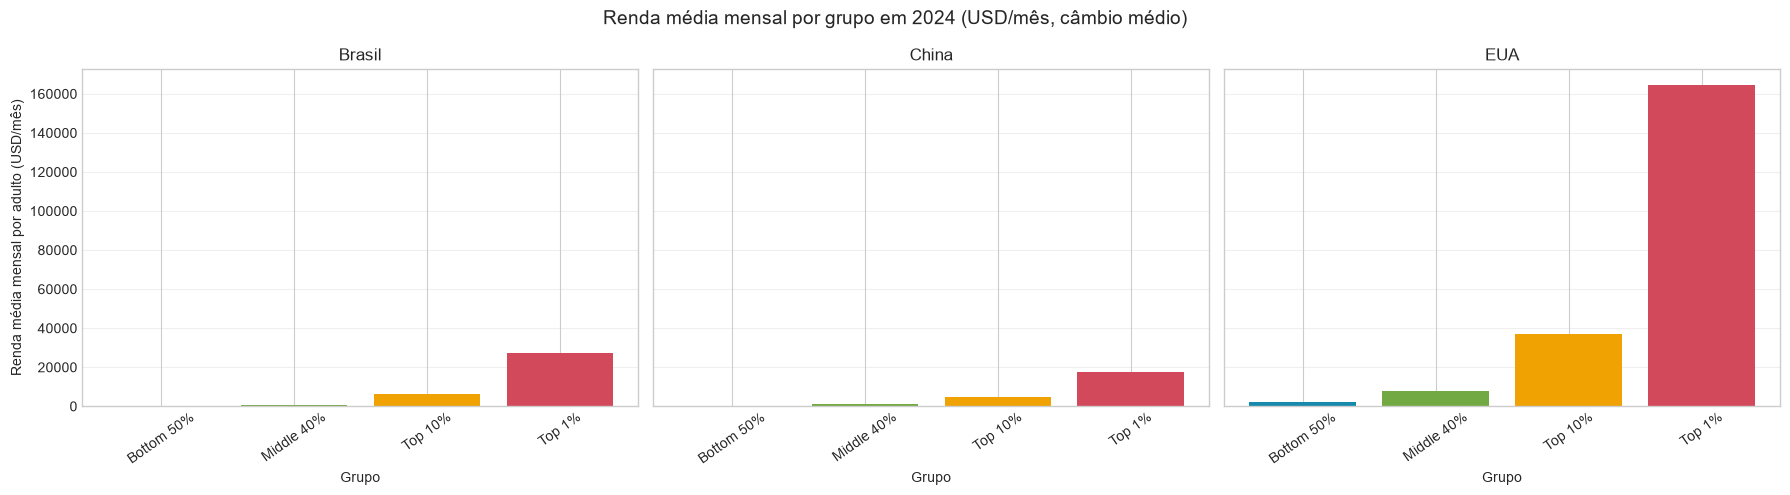

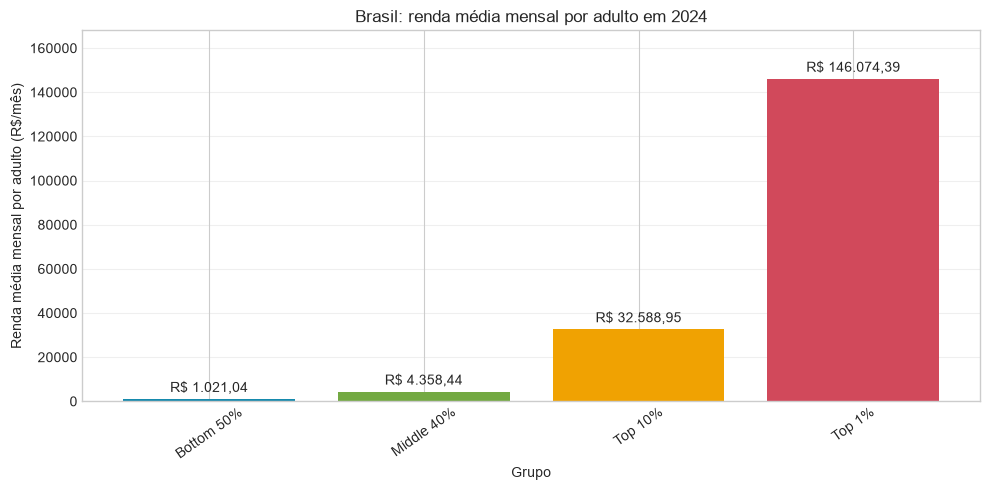

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for axis, country_name in zip(axes, WID_COUNTRIES.values()):
    country_data = income_values_2024[income_values_2024['country'].eq(country_name)]
    axis.bar(
        country_data['group'],
        country_data['income_monthly_usd'],
        color=['#168aad', '#73a942', '#f0a202', '#d1495b'],
    )
    axis.set_title(country_name)
    axis.set_xlabel('Grupo')
    axis.tick_params(axis='x', rotation=35)
    axis.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Renda média mensal por adulto (USD/mês)')
fig.suptitle('Renda média mensal por grupo em 2024 (USD/mês, câmbio médio)', fontsize=14)
fig.tight_layout()
plt.show()

brazil_income = income_values_2024[income_values_2024['country'].eq('Brasil')]
fig, axis = plt.subplots(figsize=(10, 5))
axis.bar(
    brazil_income['group'],
    brazil_income['income_monthly_local'],
    color=['#168aad', '#73a942', '#f0a202', '#d1495b'],
)
axis.bar_label(axis.containers[0], labels=[
    f'R$ {value:,.2f}'.replace(',', '_').replace('.', ',').replace('_', '.')
    for value in brazil_income['income_monthly_local']
], padding=3)
axis.margins(y=0.15)
axis.set_title('Brasil: renda média mensal por adulto em 2024')
axis.set_xlabel('Grupo')
axis.set_ylabel('Renda média mensal por adulto (R$/mês)')
axis.tick_params(axis='x', rotation=35)
axis.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Trabalho x capital

A participação da renda do trabalho mede a parcela da renda total recebida pelo trabalho:

$$Participação\ do\ trabalho = \frac{renda\ proveniente\ do\ trabalho}{renda\ total}$$

Usaremos o indicador `SDG_1041` do ILOSTAT para comparar Brasil, China e EUA no período observado de 2004 a 2024.

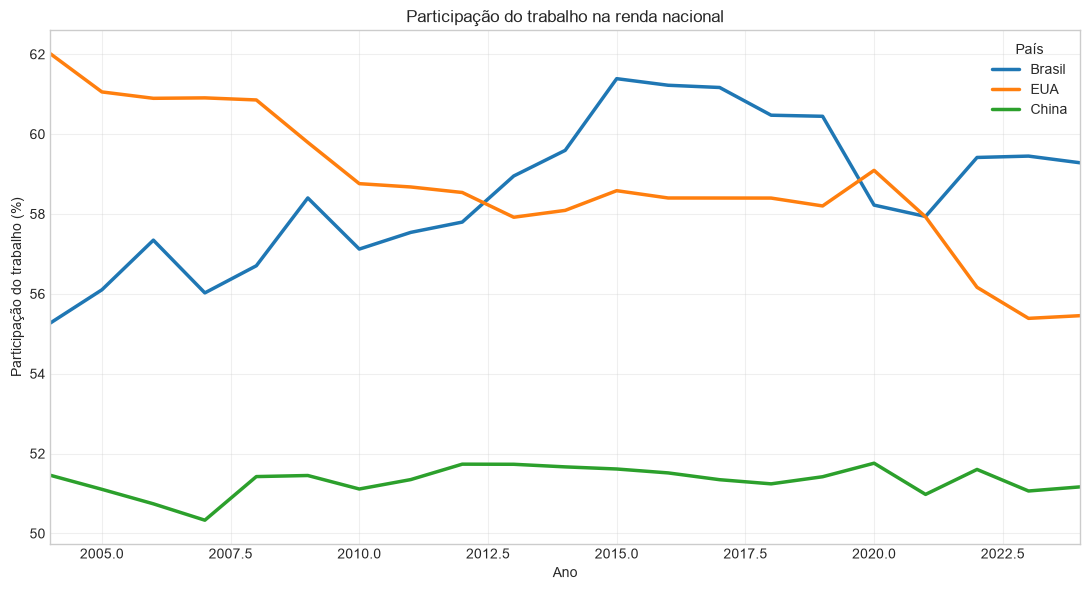

,country,source,indicator,year,share,obs_status,country_name
505,BRA,XA:2002,SDG_1041_NOC_RT,2004,55.270,NaN,Brasil
735,CHN,XA:2070,SDG_1041_NOC_RT,2004,51.455,I,China
4074,USA,XA:2174,SDG_1041_NOC_RT,2004,62.010,I,EUA


In [9]:
labor_share_path = ROOT / 'SDG_1041_NOC_RT_A-20260919T1910.csv' / 'SDG_1041_NOC_RT_A-20260919T1910.csv'
labor_share = pd.read_csv(labor_share_path)
labor_share = labor_share.rename(
    columns={'ref_area': 'country', 'time': 'year', 'obs_value': 'share'}
)
labor_share['year'] = pd.to_numeric(labor_share['year'], errors='coerce')
labor_share['share'] = pd.to_numeric(labor_share['share'], errors='coerce')
labor_share = labor_share[
    labor_share['country'].isin(COUNTRIES)
    & labor_share['year'].between(START_YEAR, END_YEAR)
].dropna(subset=['year', 'share'])
labor_share['country_name'] = labor_share['country'].map(COUNTRIES)

fig, axis = plt.subplots(figsize=(11, 6))
for country, country_name in COUNTRIES.items():
    country_data = labor_share[labor_share['country'].eq(country)]
    axis.plot(
        country_data['year'],
        country_data['share'],
        label=country_name,
        linewidth=2.5,
    )

axis.set_title('Participação do trabalho na renda nacional')
axis.set_xlabel('Ano')
axis.set_ylabel('Participação do trabalho (%)')
axis.set_xlim(START_YEAR, END_YEAR)
axis.legend(title='País')
axis.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

labor_share.groupby('country_name').tail(1).sort_values('country_name')

# 5. Renda não é riqueza

A renda é um fluxo recebido ao longo do tempo. A riqueza é um estoque de patrimônio acumulado. Por isso, nesta etapa usamos a WID para medir a participação da riqueza nacional de cada grupo:

- Bottom 50%;
- Middle 40%;
- Top 10%;
- Top 1%.

A série comparável usada é `shwealj992`, observada a partir de 2004 nos três países. Os valores são convertidos para porcentagens.

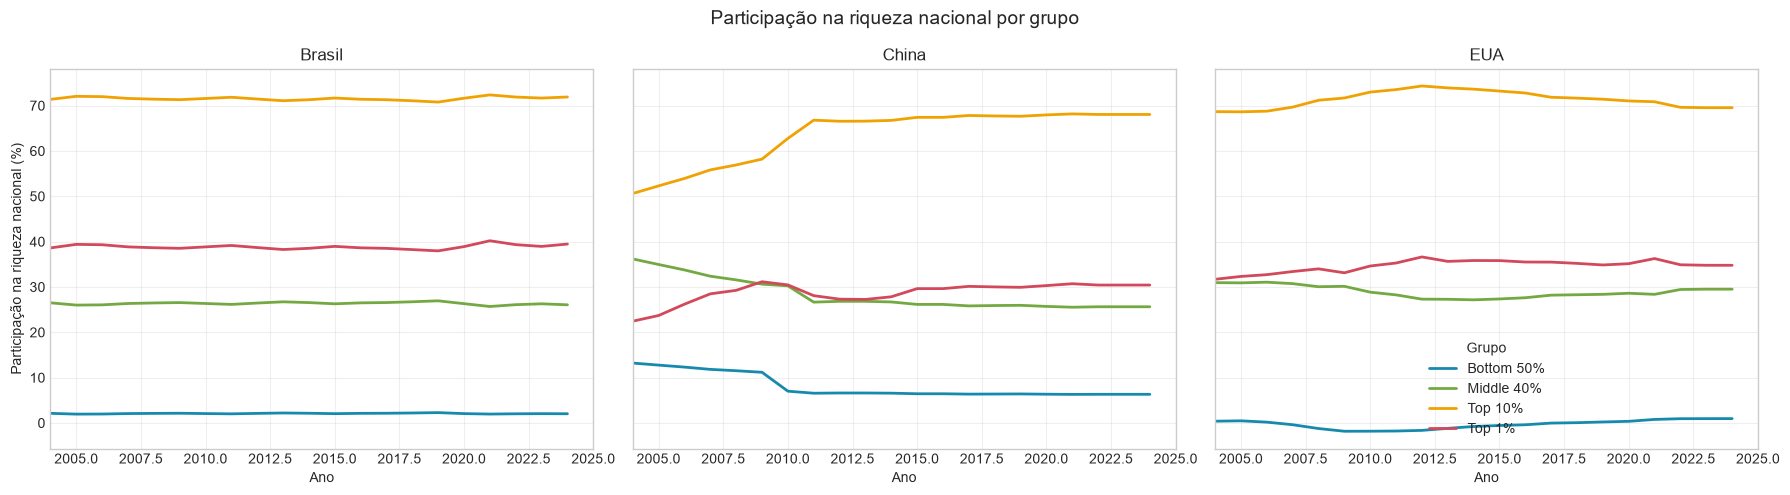

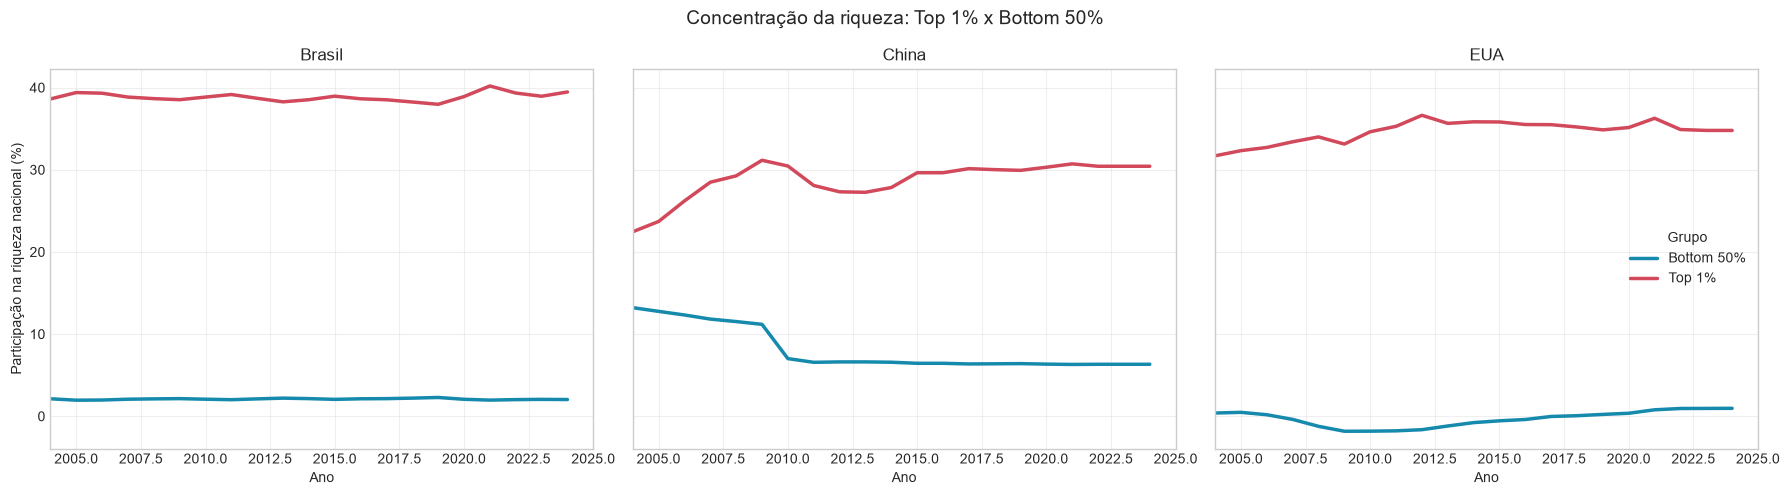

,country,year,group,wealth_share
20,Brasil,2024,Bottom 50%,2.03
41,Brasil,2024,Middle 40%,26.06
83,Brasil,2024,Top 1%,39.46
62,Brasil,2024,Top 10%,71.90
104,China,2024,Bottom 50%,6.32
125,China,2024,Middle 40%,25.63
167,China,2024,Top 1%,30.42
146,China,2024,Top 10%,68.05
188,EUA,2024,Bottom 50%,0.96
209,EUA,2024,Middle 40%,29.51


In [10]:
WEALTH_GROUPS = {
    'p0p50': 'Bottom 50%',
    'p50p90': 'Middle 40%',
    'p90p100': 'Top 10%',
    'p99p100': 'Top 1%',
}

wealth_records = []
for code, country_name in WID_COUNTRIES.items():
    wealth_path = ROOT / 'wid_all_data' / f'WID_data_{code}.csv'
    wealth_data = pd.read_csv(
        wealth_path,
        sep=';',
        usecols=['variable', 'percentile', 'year', 'value'],
        low_memory=False,
    )
    wealth_data['year'] = pd.to_numeric(wealth_data['year'], errors='coerce')
    wealth_data['value'] = pd.to_numeric(wealth_data['value'], errors='coerce')
    wealth_data = wealth_data[
        wealth_data['variable'].eq('shwealj992')
        & wealth_data['percentile'].isin(WEALTH_GROUPS)
        & wealth_data['year'].between(START_YEAR, END_YEAR)
    ].dropna(subset=['year', 'value'])
    wealth_data['country'] = country_name
    wealth_data['group'] = wealth_data['percentile'].map(WEALTH_GROUPS)
    wealth_data['wealth_share'] = wealth_data['value'] * 100
    wealth_records.append(wealth_data[['country', 'year', 'group', 'wealth_share']])

wealth = pd.concat(wealth_records, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
wealth_colors = {
    'Bottom 50%': '#168aad',
    'Middle 40%': '#73a942',
    'Top 10%': '#f0a202',
    'Top 1%': '#d1495b',
}

for axis, country_name in zip(axes, WID_COUNTRIES.values()):
    country_data = wealth[wealth['country'].eq(country_name)]
    for group, color in wealth_colors.items():
        group_data = country_data[country_data['group'].eq(group)]
        axis.plot(
            group_data['year'],
            group_data['wealth_share'],
            label=group,
            color=color,
            linewidth=2,
        )
    axis.set_title(country_name)
    axis.set_xlabel('Ano')
    axis.set_xlim(START_YEAR, None)
    axis.grid(True, alpha=0.3)

axes[0].set_ylabel('Participação na riqueza nacional (%)')
axes[-1].legend(title='Grupo', loc='best')
fig.suptitle('Participação na riqueza nacional por grupo', fontsize=14)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for axis, country_name in zip(axes, WID_COUNTRIES.values()):
    country_data = wealth[wealth['country'].eq(country_name)]
    for group, color in {
        'Bottom 50%': '#168aad',
        'Top 1%': '#d1495b',
    }.items():
        group_data = country_data[country_data['group'].eq(group)]
        axis.plot(
            group_data['year'],
            group_data['wealth_share'],
            label=group,
            color=color,
            linewidth=2.5,
        )
    axis.set_title(country_name)
    axis.set_xlabel('Ano')
    axis.set_xlim(START_YEAR, None)
    axis.grid(True, alpha=0.3)

axes[0].set_ylabel('Participação na riqueza nacional (%)')
axes[-1].legend(title='Grupo', loc='best')
fig.suptitle('Concentração da riqueza: Top 1% x Bottom 50%', fontsize=14)
fig.tight_layout()
plt.show()

wealth_2024 = wealth[wealth['year'].eq(wealth['year'].max())]
wealth_2024.sort_values(['country', 'group'])

## Valor monetário da riqueza por grupo

Além da participação percentual, usamos `ahwealj992`, que representa a **riqueza média por adulto dentro de cada grupo**. Para 2024:

- Brasil: valores originais em BRL e conversão cambial para USD;
- China: valores em CNY e conversão cambial para USD;
- EUA: valores já disponíveis em USD.

As conversões usam as taxas oficiais médias de 2024 do World Bank. Elas não ajustam diferenças de poder de compra entre países. Portanto, estes valores são médias por adulto do grupo, e não a riqueza total agregada do grupo.

In [11]:
WEALTH_AVERAGE_VARIABLE = 'ahwealj992'
CONVERSION_2024 = {
    'Brasil': {'local_currency': 'BRL', 'usd_rate': 5.3889349057096},
    'China': {'local_currency': 'CNY', 'usd_rate': 7.19749110789917},
    'EUA': {'local_currency': 'USD', 'usd_rate': 1.0},
}

wealth_value_records = []
for code, country_name in WID_COUNTRIES.items():
    value_path = ROOT / 'wid_all_data' / f'WID_data_{code}.csv'
    value_data = pd.read_csv(
        value_path,
        sep=';',
        usecols=['variable', 'percentile', 'year', 'value'],
        low_memory=False,
    )
    value_data = value_data[
        value_data['variable'].eq(WEALTH_AVERAGE_VARIABLE)
        & value_data['percentile'].isin(WEALTH_GROUPS)
        & value_data['year'].eq(END_YEAR)
    ].copy()
    value_data['country'] = country_name
    value_data['group'] = value_data['percentile'].map(WEALTH_GROUPS)
    value_data['local_currency'] = CONVERSION_2024[country_name]['local_currency']
    value_data['wealth_local'] = pd.to_numeric(value_data['value'], errors='coerce')
    value_data['wealth_usd'] = value_data['wealth_local'] / CONVERSION_2024[country_name]['usd_rate']
    wealth_value_records.append(
        value_data[['country', 'group', 'local_currency', 'wealth_local', 'wealth_usd']]
    )

wealth_values_2024 = pd.concat(wealth_value_records, ignore_index=True)
wealth_values_2024 = wealth_values_2024.sort_values(['country', 'group'])
wealth_values_2024.round({'wealth_local': 2, 'wealth_usd': 2})

,country,group,local_currency,wealth_local,wealth_usd
0,Brasil,Bottom 50%,BRL,9368.0,1738.38
1,Brasil,Middle 40%,BRL,148995.0,27648.32
3,Brasil,Top 1%,BRL,9089740.2,1686741.51
2,Brasil,Top 10%,BRL,1656496.9,307388.55
4,China,Bottom 50%,CNY,67470.3,9374.14
5,China,Middle 40%,CNY,369384.3,51321.26
7,China,Top 1%,CNY,16234423.4,2255567.00
6,China,Top 10%,CNY,3631803.8,504593.02
9,EUA,Bottom 50%,USD,10607.1,10607.10
10,EUA,Middle 40%,USD,377258.5,377258.50


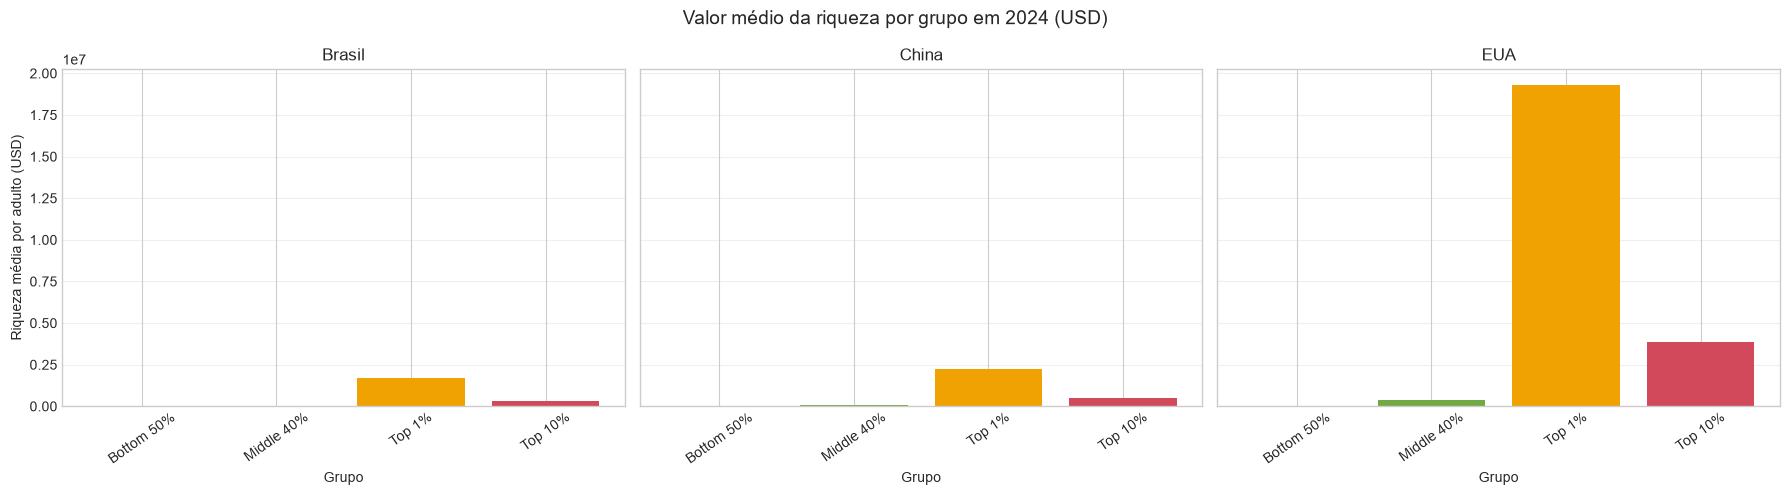

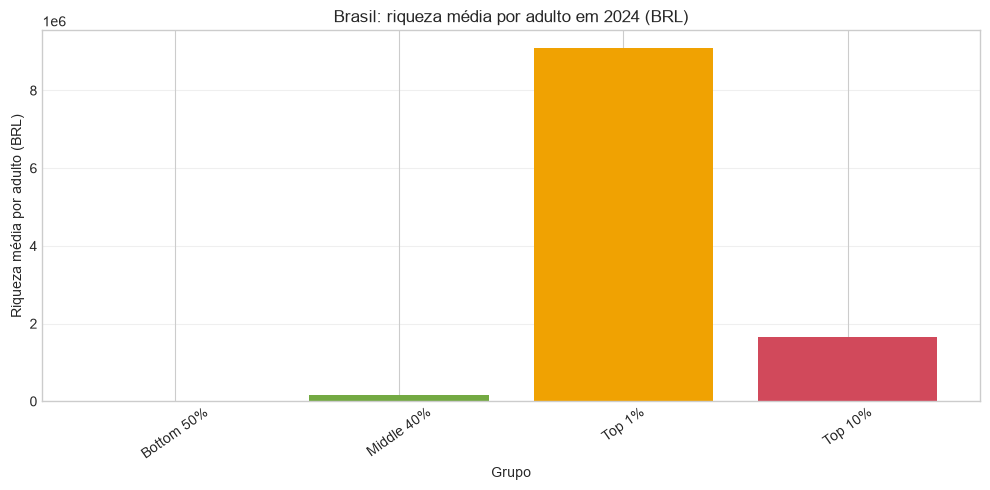

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for axis, country_name in zip(axes, WID_COUNTRIES.values()):
    country_data = wealth_values_2024[wealth_values_2024['country'].eq(country_name)]
    axis.bar(
        country_data['group'],
        country_data['wealth_usd'],
        color=['#168aad', '#73a942', '#f0a202', '#d1495b'],
    )
    axis.set_title(country_name)
    axis.set_xlabel('Grupo')
    axis.tick_params(axis='x', rotation=35)
    axis.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Riqueza média por adulto (USD)')
fig.suptitle('Valor médio da riqueza por grupo em 2024 (USD)', fontsize=14)
fig.tight_layout()
plt.show()

brazil_values = wealth_values_2024[wealth_values_2024['country'].eq('Brasil')]
fig, axis = plt.subplots(figsize=(10, 5))
axis.bar(
    brazil_values['group'],
    brazil_values['wealth_local'],
    color=['#168aad', '#73a942', '#f0a202', '#d1495b'],
)
axis.set_title('Brasil: riqueza média por adulto em 2024 (BRL)')
axis.set_xlabel('Grupo')
axis.set_ylabel('Riqueza média por adulto (BRL)')
axis.tick_params(axis='x', rotation=35)
axis.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Quem ficou com o crescimento?

A participação na renda mostra a distribuição, mas não mede diretamente quanto a renda de cada grupo cresceu. Para isso, usamos a renda média real por grupo da WID (`aptincj992`) e calculamos:

$$Crescimento_g = \left(\frac{Renda_{g,2024}}{Renda_{g,2004}} - 1\right) \times 100$$

A comparação será feita de 2004 a 2024, período comum às principais séries utilizadas.

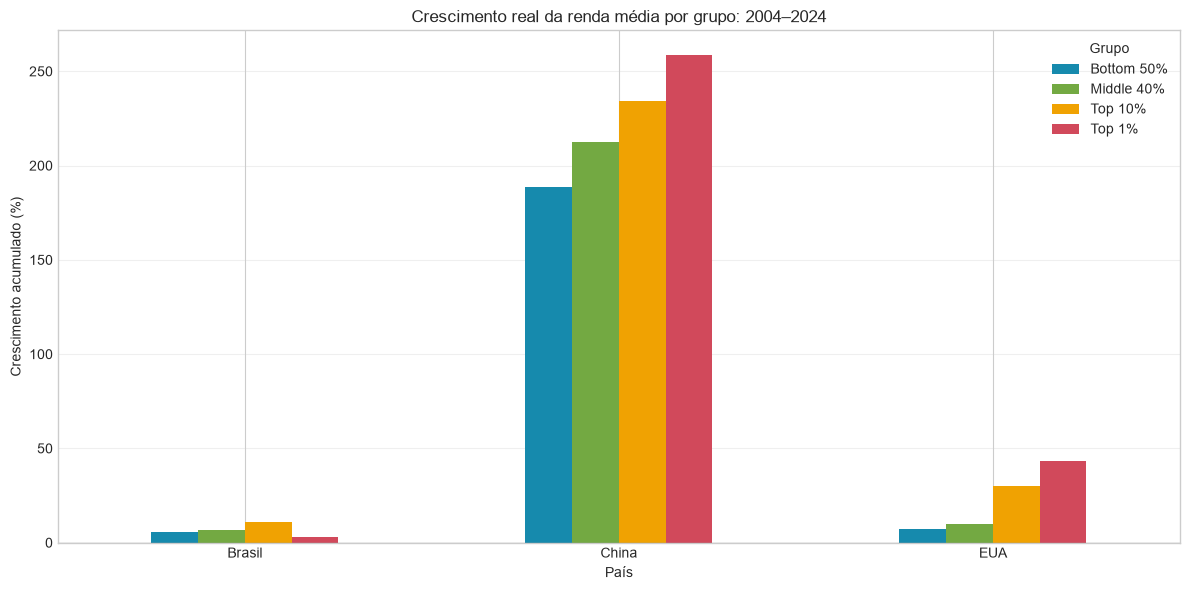

year,country,group,2004,2024,growth_pct
0,Brasil,Bottom 50%,11590.4,12252.5,5.712486
1,Brasil,Middle 40%,48911.4,52301.3,6.930695
2,Brasil,Top 1%,1704697.8,1752892.7,2.827181
3,Brasil,Top 10%,352867.7,391067.4,10.825502
4,China,Bottom 50%,9098.9,26245.0,188.441460
5,China,Middle 40%,33434.9,104523.1,212.616757
6,China,Top 1%,426899.7,1531316.4,258.706366
7,China,Top 10%,126292.4,422183.5,234.290504
8,EUA,Bottom 50%,23859.9,25604.0,7.309754
9,EUA,Middle 40%,86326.7,94816.0,9.833922


In [13]:
income_level_records = []
for code, country_name in WID_COUNTRIES.items():
    income_path = ROOT / 'wid_all_data' / f'WID_data_{code}.csv'
    income_data = pd.read_csv(
        income_path,
        sep=';',
        usecols=['variable', 'percentile', 'year', 'value'],
        low_memory=False,
    )
    income_data['year'] = pd.to_numeric(income_data['year'], errors='coerce')
    income_data['value'] = pd.to_numeric(income_data['value'], errors='coerce')
    income_data = income_data[
        income_data['variable'].eq('aptincj992')
        & income_data['percentile'].isin(WEALTH_GROUPS)
        & income_data['year'].between(START_YEAR, END_YEAR)
    ].dropna(subset=['year', 'value'])
    income_data['country'] = country_name
    income_data['group'] = income_data['percentile'].map(WEALTH_GROUPS)
    income_level_records.append(income_data[['country', 'year', 'group', 'value']])

income_levels = pd.concat(income_level_records, ignore_index=True)
income_levels = income_levels.rename(columns={'value': 'real_income'})

income_growth = (
    income_levels[income_levels['year'].isin([START_YEAR, END_YEAR])]
    .pivot_table(index=['country', 'group'], columns='year', values='real_income', aggfunc='mean')
    .reset_index()
)
income_growth['growth_pct'] = (
    income_growth[END_YEAR] / income_growth[START_YEAR] - 1
) * 100

fig, axis = plt.subplots(figsize=(12, 6))
income_growth.pivot(index='country', columns='group', values='growth_pct').reindex(
    columns=['Bottom 50%', 'Middle 40%', 'Top 10%', 'Top 1%']
).plot(kind='bar', ax=axis, color=['#168aad', '#73a942', '#f0a202', '#d1495b'])
axis.set_title('Crescimento real da renda média por grupo: 2004–2024')
axis.set_xlabel('País')
axis.set_ylabel('Crescimento acumulado (%)')
axis.axhline(0, color='black', linewidth=0.8)
axis.legend(title='Grupo')
axis.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

income_growth.sort_values(['country', 'group'])

# 7. Pipeline quantitativo reproduzível

Agora integramos as fontes em um único painel anual:

**WID + World Bank + ILOSTAT -> limpeza -> merge -> estatística -> visualização**

Usaremos as variações anuais da produtividade e da renda média para testar duas relações:

$$corr(\Delta produtividade, \Delta renda_{Bottom50})$$

$$corr(\Delta produtividade, \Delta renda_{Top1})$$

O painel começa em 2004. As correlações são descritivas e não provam causalidade.

In [14]:
productivity_panel = productivity[['country_name', 'year', 'productivity']].rename(
    columns={'country_name': 'country'}
)
income_panel = income_levels.pivot_table(
    index=['country', 'year'],
    columns='group',
    values='real_income',
    aggfunc='mean',
).reset_index()

panel = productivity_panel.merge(
    income_panel,
    on=['country', 'year'],
    how='inner',
    validate='one_to_one',
)
panel = panel.sort_values(['country', 'year']).reset_index(drop=True)
panel['productivity_growth'] = panel.groupby('country')['productivity'].pct_change() * 100
for group in ['Bottom 50%', 'Top 1%']:
    panel[f'{group}_growth'] = panel.groupby('country')[group].pct_change() * 100

panel.head()

,country,year,productivity,Bottom 50%,Middle 40%,Top 1%,Top 10%,productivity_growth,Bottom 50%_growth,Top 1%_growth
0,Brasil,2004,34011.64,11590.4,48911.4,1704697.8,352867.7,NaN,NaN,NaN
1,Brasil,2005,34309.22,11087.8,46555.2,1731087.7,369906.5,0.874936,-4.336347,1.548069
2,Brasil,2006,34899.89,11594.6,47121.1,1798335.0,375780.2,1.721607,4.570790,3.884685
3,Brasil,2007,36462.80,12930.0,50653.2,1944446.8,381125.3,4.478266,11.517431,8.124838
4,Brasil,2008,37362.22,13628.0,52492.1,1958938.8,391055.0,2.466678,5.398299,0.745302


In [15]:
correlation_rows = []
for country, country_data in panel.groupby('country'):
    valid_data = country_data.dropna(
        subset=['productivity_growth', 'Bottom 50%_growth', 'Top 1%_growth']
    )
    correlation_rows.append({
        'country': country,
        'corr_productivity_bottom50': valid_data['productivity_growth'].corr(
            valid_data['Bottom 50%_growth']
        ),
        'corr_productivity_top1': valid_data['productivity_growth'].corr(
            valid_data['Top 1%_growth']
        ),
        'observations': len(valid_data),
    })

correlations = pd.DataFrame(correlation_rows)
correlations

,country,corr_productivity_bottom50,corr_productivity_top1,observations
0,Brasil,-0.016544,0.699066,20
1,China,0.485773,0.526507,20
2,EUA,-0.010853,0.057037,20


In [16]:
growth_comparison = income_growth.pivot_table(
    index='country',
    columns='group',
    values='growth_pct',
    aggfunc='mean',
).reindex(columns=['Bottom 50%', 'Middle 40%', 'Top 10%', 'Top 1%'])
growth_comparison['Productividade'] = (
    panel.groupby('country')['productivity'].agg(lambda values: (values.iloc[-1] / values.iloc[0] - 1) * 100)
)
growth_comparison['Bottom50_por_produtividade'] = (
    growth_comparison['Bottom 50%'] / growth_comparison['Productividade']
)
growth_comparison['Top1_por_produtividade'] = (
    growth_comparison['Top 1%'] / growth_comparison['Productividade']
)
growth_comparison.round(2)

group,Bottom 50%,Middle 40%,Top 10%,Top 1%,Productividade,Bottom50_por_produtividade,Top1_por_produtividade
country,,,,,,,
Brasil,5.71,6.93,10.83,2.83,21.82,0.26,0.13
China,188.44,212.62,234.29,258.71,341.32,0.55,0.76
EUA,7.31,9.83,30.14,43.54,27.17,0.27,1.60


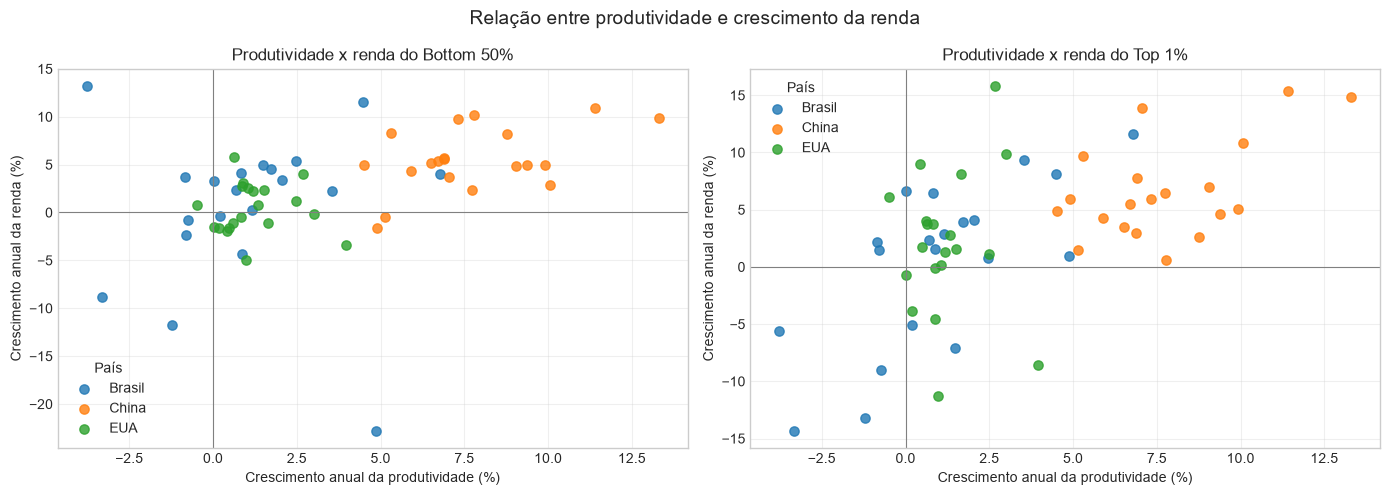

In [17]:
plot_data = panel.dropna(
    subset=['productivity_growth', 'Bottom 50%_growth', 'Top 1%_growth']
).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for country, country_data in plot_data.groupby('country'):
    axes[0].scatter(
        country_data['productivity_growth'],
        country_data['Bottom 50%_growth'],
        label=country,
        s=45,
        alpha=0.8,
    )
    axes[1].scatter(
        country_data['productivity_growth'],
        country_data['Top 1%_growth'],
        label=country,
        s=45,
        alpha=0.8,
    )

axes[0].set_title('Produtividade x renda do Bottom 50%')
axes[0].set_ylabel('Crescimento anual da renda (%)')
axes[1].set_title('Produtividade x renda do Top 1%')
axes[1].set_ylabel('Crescimento anual da renda (%)')
for axis in axes:
    axis.set_xlabel('Crescimento anual da produtividade (%)')
    axis.axhline(0, color='gray', linewidth=0.8)
    axis.axvline(0, color='gray', linewidth=0.8)
    axis.grid(True, alpha=0.3)
    axis.legend(title='País')
fig.suptitle('Relação entre produtividade e crescimento da renda', fontsize=14)
fig.tight_layout()
plt.show()

# 9. Mobilidade estrutural: emprego por setor

Os dados do World Bank permitem comparar a participação do emprego em agricultura, indústria e serviços para Brasil, China e EUA. Essa dimensão ajuda a interpretar diferenças como estágios distintos de urbanização e transformação produtiva.

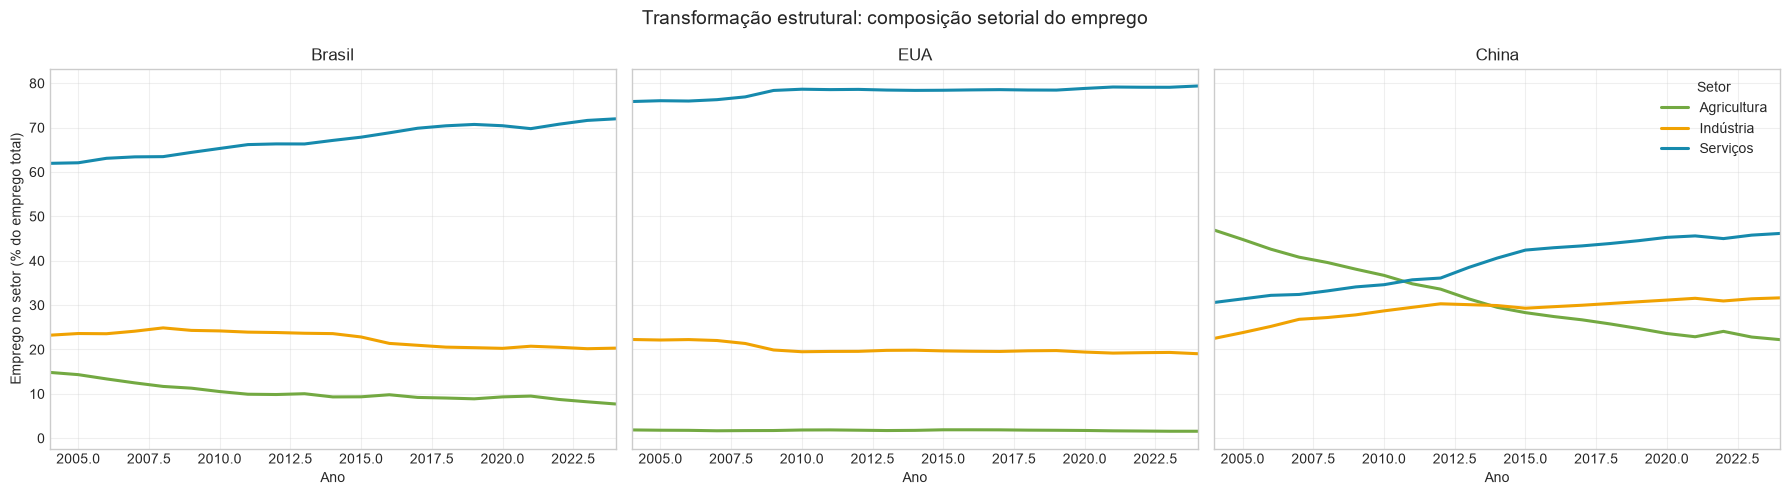

,country_name,year,sector,value
20,Brazil,2024,Agricultura,7.715652
83,Brazil,2024,Indústria,20.302225
146,Brazil,2024,Serviços,71.982123
41,China,2024,Agricultura,22.216498
104,China,2024,Indústria,31.632444
167,China,2024,Serviços,46.151060
62,United States,2024,Agricultura,1.568992
125,United States,2024,Indústria,19.043707
188,United States,2024,Serviços,79.387301


In [18]:
SECTOR_INDICATORS = {
    'SL.AGR.EMPL.ZS': 'Agricultura',
    'SL.IND.EMPL.ZS': 'Indústria',
    'SL.SRV.EMPL.ZS': 'Serviços',
}

sector_records = []
for indicator, sector in SECTOR_INDICATORS.items():
    sector_path = ROOT / 'world_bank_sector_employment' / f'{indicator}.csv'
    sector_data = pd.read_csv(sector_path)
    sector_data['year'] = pd.to_numeric(sector_data['year'], errors='coerce')
    sector_data['value'] = pd.to_numeric(sector_data['value'], errors='coerce')
    sector_data['sector'] = sector
    sector_records.append(
        sector_data[
            sector_data['country'].isin(COUNTRIES)
            & sector_data['year'].between(START_YEAR, END_YEAR)
        ][['country', 'country_name', 'year', 'value', 'sector']]
    )

sector_employment = pd.concat(sector_records, ignore_index=True).dropna(
    subset=['country', 'year', 'value']
)
sector_employment = sector_employment.sort_values(['country', 'year', 'sector'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
sector_colors = {
    'Agricultura': '#73a942',
    'Indústria': '#f0a202',
    'Serviços': '#168aad',
}

for axis, country in zip(axes, COUNTRIES):
    country_data = sector_employment[sector_employment['country'].eq(country)]
    for sector, color in sector_colors.items():
        sector_data = country_data[country_data['sector'].eq(sector)]
        axis.plot(
            sector_data['year'],
            sector_data['value'],
            label=sector,
            color=color,
            linewidth=2.2,
        )
    axis.set_title(COUNTRIES[country])
    axis.set_xlabel('Ano')
    axis.set_xlim(START_YEAR, END_YEAR)
    axis.grid(True, alpha=0.3)

axes[0].set_ylabel('Emprego no setor (% do emprego total)')
axes[-1].legend(title='Setor')
fig.suptitle('Transformação estrutural: composição setorial do emprego', fontsize=14)
fig.tight_layout()
plt.show()

latest_sector = (
    sector_employment.sort_values('year')
    .groupby(['country_name', 'sector'], as_index=False)
    .tail(1)
    .sort_values(['country_name', 'sector'])
)
latest_sector[['country_name', 'year', 'sector', 'value']]